# Ray API sketch

A minimal cartesian ray-tracing example using the current batcamp API.

In [1]:
from batread import Dataset
import matplotlib.pyplot as plt
import numpy as np

from batcamp import Octree, OctreeInterpolator, OctreeRayTracer

ds = Dataset.from_file("../sample_data/3d__var_2_n00006003.plt")
tree = Octree.from_ds(ds, tree_coord="xyz")
interp = OctreeInterpolator(tree, ds["Rho [g/cm^3]"])
tracer = OctreeRayTracer(tree)

tree, interp, tracer


(<batcamp.octree.Octree at 0x122453620>,
 <batcamp.ray.OctreeRayTracer at 0x122453b60>)

In [2]:
coords = np.linspace(-24.0, 24.0, 64)
y, z = np.meshgrid(coords, coords, indexing="xy")
origins = np.stack((np.full_like(y, -24.0), y, z), axis=-1)
directions = np.array([1.0, 0.0, 0.0], dtype=float)

origins.shape, directions.shape


((64, 64, 3), (3,))

In [3]:
segments = tracer.trace(origins, directions)
cell_counts = np.diff(segments.ray_offsets).reshape(y.shape)

int(cell_counts.min()), float(np.median(cell_counts)), int(cell_counts.max())


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(14, 16.0, 18)

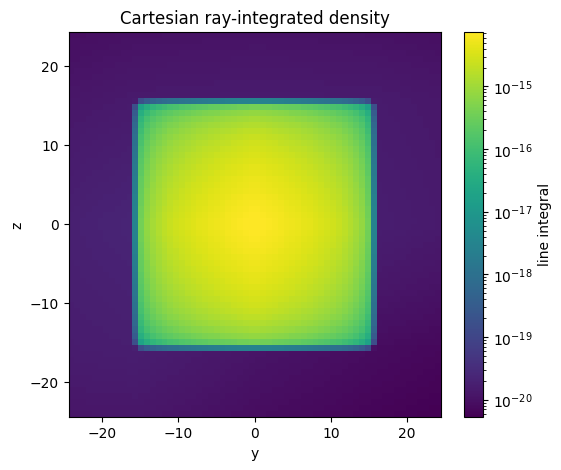

(64, 64)

In [4]:
rho_los, _ = tracer.accumulate_exact_image(interp, origins, directions)

fig, ax = plt.subplots(figsize=(6, 5))
mesh = ax.pcolormesh(y, z, rho_los, shading="auto", norm="log")
ax.set_xlabel("y")
ax.set_ylabel("z")
ax.set_title("Cartesian ray-integrated density")
fig.colorbar(mesh, ax=ax, label="line integral")
plt.show()

rho_los.shape
